In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem import AllChem, SDWriter
import pandas as pd
import os
import sys
root_path="/home/iaw/DATA2/AAReact/src"
sys.path.append(root_path)
from tool.mol_tool import add_dative, check_atom_charge, correct_valence, repair_mol2_and_save_as_sdf
from config.constants import XTB_BACHEND, OBABEL_BACHEND

# preprocess cat-63
- The provided mol2 file has already had bonds with metal ions removed. and this mol2 file was saved from `Gaussian View 16` in the `Sybyl Mol2` format.
  - Additionally, we manually corrected the aromatic bonds in the molecule and converted them to `Kekule` form.
- The molecular conformation recorded in the mol2 file was optimized using XTB.Details are provided in `./1_xtb_opt/xtb_opt_md.sh`.
## Repair of coordinate bonds
- input format: `[(int_1, (int2, ...)), ....]`
  - `(int_1, (int2, ...))`: group1
  - `int_1`: ion atom in group1
  - `(int2, ...)`: coordinating atoms in group1
- Index of metal atoms: `0`, 
- Index of coordinating atoms: `62, 61, 1, 2`
  - This index is 0-based.
## Adjust the charges and valences of atoms involved in coordination
- input format: `[(int_1, int_2, int_3), ...]`
  - `(int_1, int_2, int_3)`: atom1
  - `int_1`: index (0-based) of atom1
  - `int_2`: NumRadicalElectrons of atom1
  - `int_3`: FormalCharge of atom1
- Ru2+: `(0, 0, +2)`

In [4]:
smi_fixed, mol_fixed = repair_mol2_and_save_as_sdf(
    mol_name = "CAT-63", 
    mol2_fp = "./1_xtb_opt/CAT-63_new.mol2", 
    sdf_saved_fp = "./2_FINAL/CAT-63.sdf", 
    ion_coor_s = [(0, [62, 61, 1, 2])], 
    valence_info_s = [ (0, 0, +2)]
)
print("Info[iaw]:> Fixed smiles: `{}`".format(smi_fixed))
check_atom_charge(mol_fixed, [0])
check_atom_charge(mol_fixed, [62, 61, 1, 2])

Info[iaw]:> Fixed smiles: `[H]c1c([H])c2[P](c3c([H])c(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])c(OC([H])([H])[H])c(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])c3[H])(c3c([H])c(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])c(OC([H])([H])[H])c(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])c3[H])->[Ru+2](<-[O-]C(=O)C([H])([H])[H])(<-[O-]C(=O)C([H])([H])[H])<-[P](c3c([H])c(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])c(OC([H])([H])[H])c(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])c3[H])(c3c([H])c(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])c(OC([H])([H])[H])c(C(C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])c3[H])c3c([H])c([H])c4c(c3-c2c2c1OC([H])([H])O2)OC([H])([H])O4`
Info[iaw]>: ATOM[Ru-0], Charge: 2, Valence: 4, RadicalElectron: 0
Info[iaw]>: ATOM[O-62], Charge: -1, Valence: 1, RadicalElectron: 0
Info[iaw]>: ATOM[O-61], Charge: -1, Valence: 1, RadicalElectron: 0
Info[iaw]>: ATOM[P-1], Charge: 0, Valence: 3, RadicalElectron: 0
Info[iaw]>: ATOM[P-2], Charge: 0, V

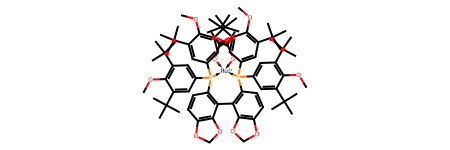

In [5]:
Chem.MolFromSmiles(smi_fixed)